In [9]:
!pip install opencv-python
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install scikit-image


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user insta

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as quan  
import matplotlib
from scipy.fft import fftn, fftshift
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
import skimage




[2] Hiển thị ảnh gốc dog.png


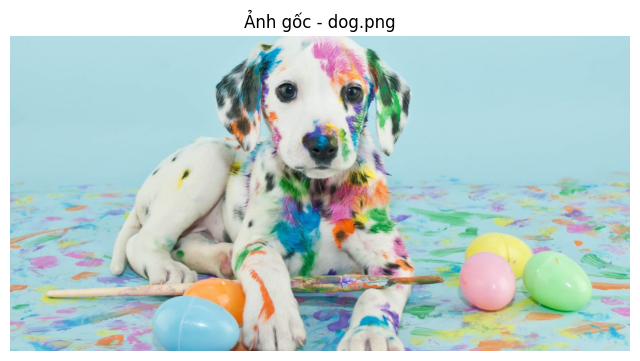

  ✅ Đã hiển thị ảnh.


In [11]:
print("\n[2] Hiển thị ảnh gốc dog.png")

img = cv2.imread('dog.png')
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    quan.figure(figsize=(8, 6))
    quan.imshow(img_rgb)
    quan.title('Ảnh gốc - dog.png')
    quan.axis('off')
    quan.show()
    print("  ✅ Đã hiển thị ảnh.")
else:
    print("  ❌ Không đọc được ảnh. Kiểm tra lại file dog.png.")


[3] Thực hiện FFT trên ảnh dog.png


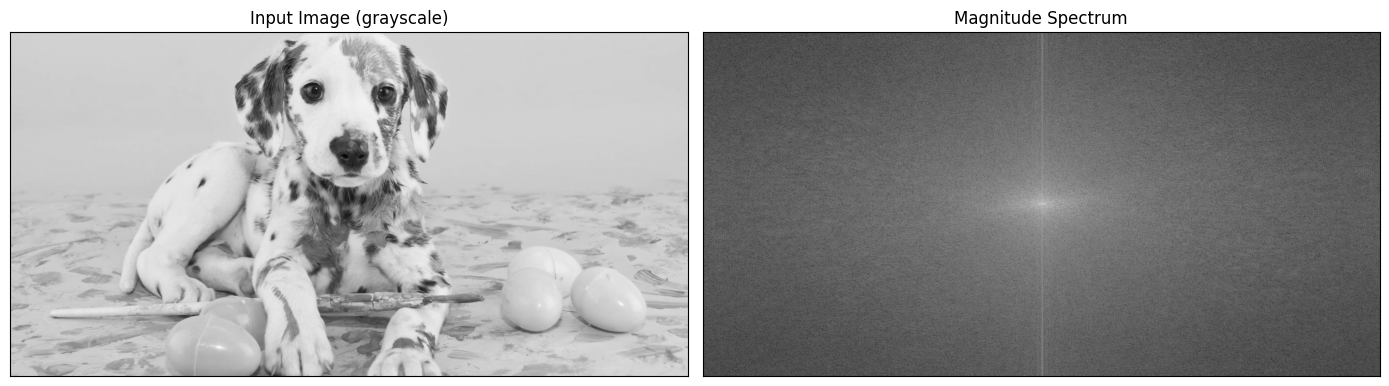

  ✅ Đã hiển thị ảnh gốc (grayscale) và phổ tần số.


In [12]:
print("\n[3] Thực hiện FFT trên ảnh dog.png")

# Đọc ảnh xám
img_gray = cv2.imread('dog.png', 0)
if img_gray is not None:
    # Chuyển sang float32
    img_float32 = np.float32(img_gray)
    
    # DFT
    dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    
    # Tính magnitude spectrum (log scale)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)
    
    # Hiển thị
    quan.figure(figsize=(14, 6))
    
    quan.subplot(121)
    quan.imshow(img_gray, cmap='gray')
    quan.title('Input Image (grayscale)')
    quan.xticks([]), quan.yticks([])
    
    quan.subplot(122)
    quan.imshow(magnitude_spectrum, cmap='gray')
    quan.title('Magnitude Spectrum')
    quan.xticks([]), quan.yticks([])
    
    quan.tight_layout()
    quan.show()
    print("  ✅ Đã hiển thị ảnh gốc (grayscale) và phổ tần số.")
else:
    print("  ❌ Không đọc được ảnh.")

In [13]:
print("\n[4] Phát hiện ảnh mờ bằng FFT (so sánh ảnh gốc và ảnh đã lọc DoG)")

try:
    image = gravel()
    print("  ✅ Đã tải ảnh mẫu 'gravel' từ skimage")
    
    # Áp dụng cửa sổ Hann
    wimage = image * window('hann', image.shape)
    
    # Difference of Gaussians (band-pass)
    filtered_image = difference_of_gaussians(image, 1, 12)
    filtered_wimage = filtered_image * window('hann', image.shape)
    
    # FFT
    im_f_mag = fftshift(np.abs(fftn(wimage)))
    fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
    
    # Vẽ kết quả
    fig, ax = TenSV.subplots(nrows=2, ncols=2, figsize=(10, 10))
    
    ax[0, 0].imshow(image, cmap='gray')
    ax[0, 0].set_title('Original Image')
    ax[0, 0].axis('off')
    
    ax[0, 1].imshow(np.log(im_f_mag + 1), cmap='magma')
    ax[0, 1].set_title('Original FFT Magnitude (log)')
    ax[0, 1].axis('off')
    
    ax[1, 0].imshow(filtered_image, cmap='gray')
    ax[1, 0].set_title('Filtered Image (DoG)')
    ax[1, 0].axis('off')
    
    ax[1, 1].imshow(np.log(fim_f_mag + 1), cmap='magma')
    ax[1, 1].set_title('Filtered FFT Magnitude (log)')
    ax[1, 1].axis('off')
    
    quan.tight_layout()
    quan.show()
    print("  ✅ Đã hiển thị so sánh.")
    
    
except Exception as e:
    print(f"  ❌ Lỗi: {e}")


[4] Phát hiện ảnh mờ bằng FFT (so sánh ảnh gốc và ảnh đã lọc DoG)
  ✅ Đã tải ảnh mẫu 'gravel' từ skimage
  ❌ Lỗi: name 'TenSV' is not defined



[5] Harris Corner Detection trên dog.png

[5.1] Harris với threshold = 0.005


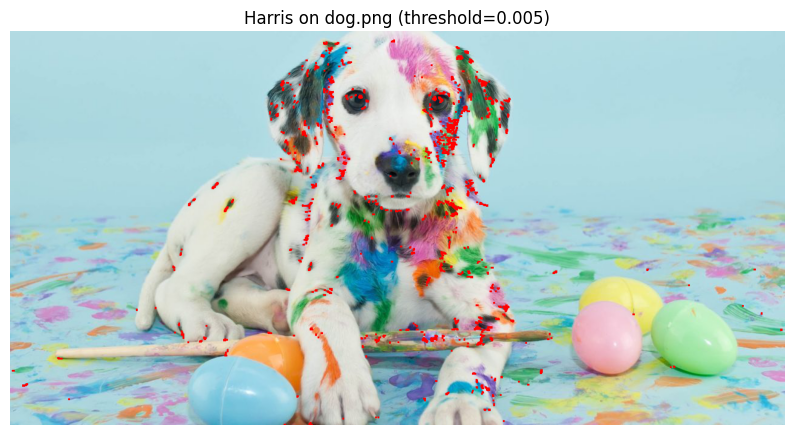

  ✅ Đã lưu kết quả vào example_dog.jpg

[5.2] Harris với threshold = 0.01


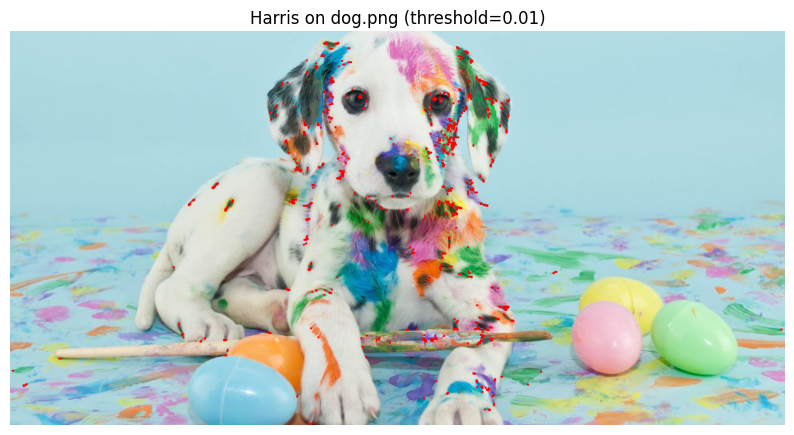

In [14]:
print("\n[5] Harris Corner Detection trên dog.png")

def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, blockSize, ksize, k)
    dst = cv2.dilate(dst, None)  # Làm rõ các điểm góc
    img[dst > threshold * dst.max()] = [0, 0, 255]  # Đánh dấu đỏ
    return img

# Thử với threshold = 0.005
print("\n[5.1] Harris với threshold = 0.005")
result1 = detect_corner('dog.png', blockSize=2, ksize=5, k=0.04, threshold=0.005)
if result1 is not None:
    quan.figure(figsize=(10, 8))
    quan.imshow(cv2.cvtColor(result1, cv2.COLOR_BGR2RGB))
    quan.title('Harris on dog.png (threshold=0.005)')
    quan.axis('off')
    quan.show()
    cv2.imwrite('example_dog.jpg', result1)
    print("  ✅ Đã lưu kết quả vào example_dog.jpg")

# Thử với threshold = 0.01
print("\n[5.2] Harris với threshold = 0.01")
result2 = detect_corner('dog.png', blockSize=2, ksize=5, k=0.04, threshold=0.01)
if result2 is not None:
    quan.figure(figsize=(10, 8))
    quan.imshow(cv2.cvtColor(result2, cv2.COLOR_BGR2RGB))
    quan.title('Harris on dog.png (threshold=0.01)')
    quan.axis('off')
    quan.show()




[6] Band-pass filtering by Difference of Gaussians (chi tiết)


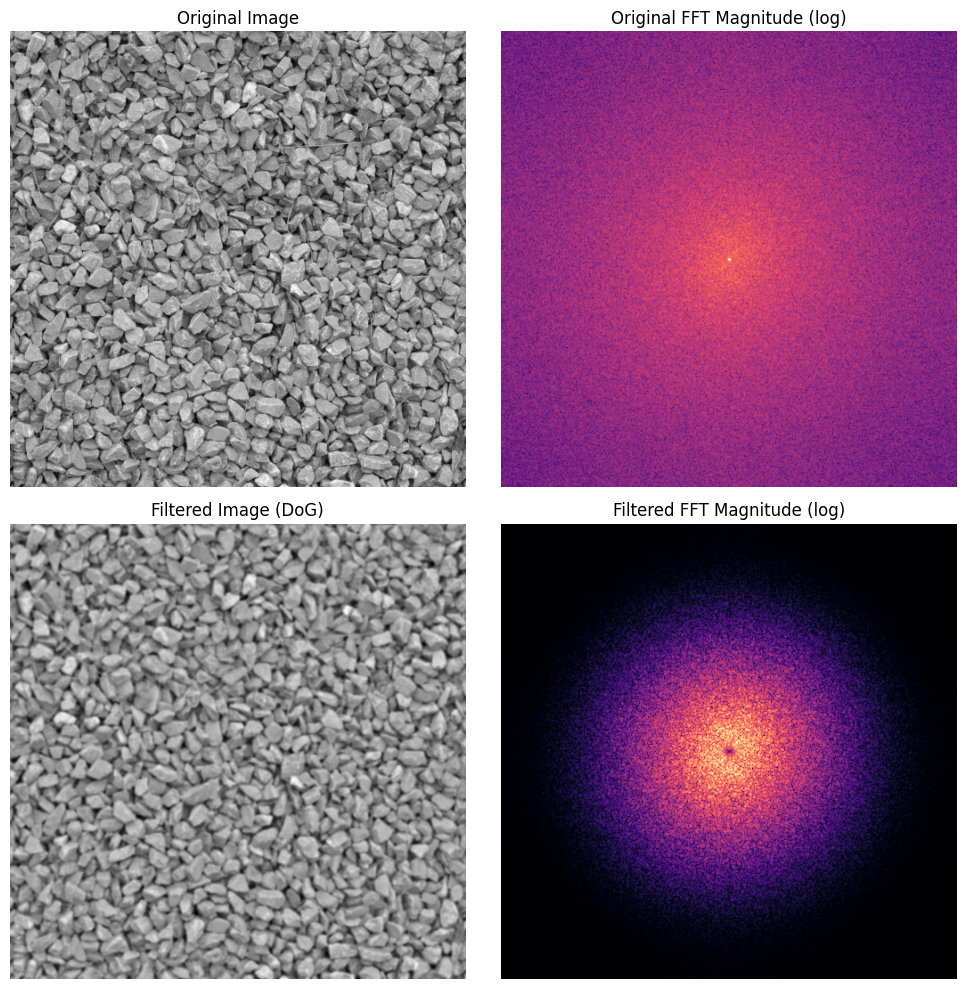

In [16]:
print("\n[6] Band-pass filtering by Difference of Gaussians (chi tiết)")

try:
    image = gravel()
    wimage = image * window('hann', image.shape)
    filtered_image = difference_of_gaussians(image, 1, 12)
    filtered_wimage = filtered_image * window('hann', image.shape)
    im_f_mag = fftshift(np.abs(fftn(wimage)))
    fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))
    
    fig, ax = quan.subplots(nrows=2, ncols=2, figsize=(10, 10))
    
    ax[0, 0].imshow(image, cmap='gray')
    ax[0, 0].set_title('Original Image')
    ax[0, 0].axis('off')
    
    ax[0, 1].imshow(np.log(im_f_mag + 1), cmap='magma')
    ax[0, 1].set_title('Original FFT Magnitude (log)')
    ax[0, 1].axis('off')
    
    ax[1, 0].imshow(filtered_image, cmap='gray')
    ax[1, 0].set_title('Filtered Image (DoG)')
    ax[1, 0].axis('off')
    
    ax[1, 1].imshow(np.log(fim_f_mag + 1), cmap='magma')
    ax[1, 1].set_title('Filtered FFT Magnitude (log)')
    ax[1, 1].axis('off')
    
    quan.tight_layout()
    quan.show()
    
except Exception as e:
    print(f"  ❌ Lỗi: {e}")